In [39]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from binance.client import Client
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import GridSearchCV

In [40]:
api_key = os.getenv("BINANCE_API_KEY")
api_secret = os.getenv("BINANCE_API_SECRET")
client = Client(api_key, api_secret)


klines = client.get_historical_klines(
    "BTCUSDT", 
    Client.KLINE_INTERVAL_1MINUTE, 
    "30 day ago UTC"
)

df1 = pd.DataFrame(klines, columns=[
    "timestamp","Open","High","Low","Close","Volume",
    "Close_time","Quote_asset_volume","Number_of_trades",
    "Taker_buy_base","Taker_buy_quote","Ignore"
])

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43200 entries, 0 to 43199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   timestamp           43200 non-null  int64 
 1   Open                43200 non-null  object
 2   High                43200 non-null  object
 3   Low                 43200 non-null  object
 4   Close               43200 non-null  object
 5   Volume              43200 non-null  object
 6   Close_time          43200 non-null  int64 
 7   Quote_asset_volume  43200 non-null  object
 8   Number_of_trades    43200 non-null  int64 
 9   Taker_buy_base      43200 non-null  object
 10  Taker_buy_quote     43200 non-null  object
 11  Ignore              43200 non-null  object
dtypes: int64(3), object(9)
memory usage: 4.0+ MB


In [41]:
import importlib
import build_feature

df = df1.copy()
importlib.reload(build_feature)

df = build_feature.build_features(df)

df.to_csv("features.csv", index=False)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43180 entries, 0 to 43179
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           43180 non-null  datetime64[ns]
 1   Close          43180 non-null  float64       
 2   ma_5           43180 non-null  float64       
 3   ma_10          43180 non-null  float64       
 4   ma_diff        43180 non-null  float64       
 5   RSI_14         43180 non-null  float64       
 6   ROC_10         43180 non-null  float64       
 7   MACD           43180 non-null  float64       
 8   MACD_signal    43180 non-null  float64       
 9   BB_upper       43180 non-null  float64       
 10  BB_lower       43180 non-null  float64       
 11  BB_width       43180 non-null  float64       
 12  volatility_20  43180 non-null  float64       
 13  %K             43180 non-null  float64       
 14  %D             43180 non-null  float64       
 15  signal         4318

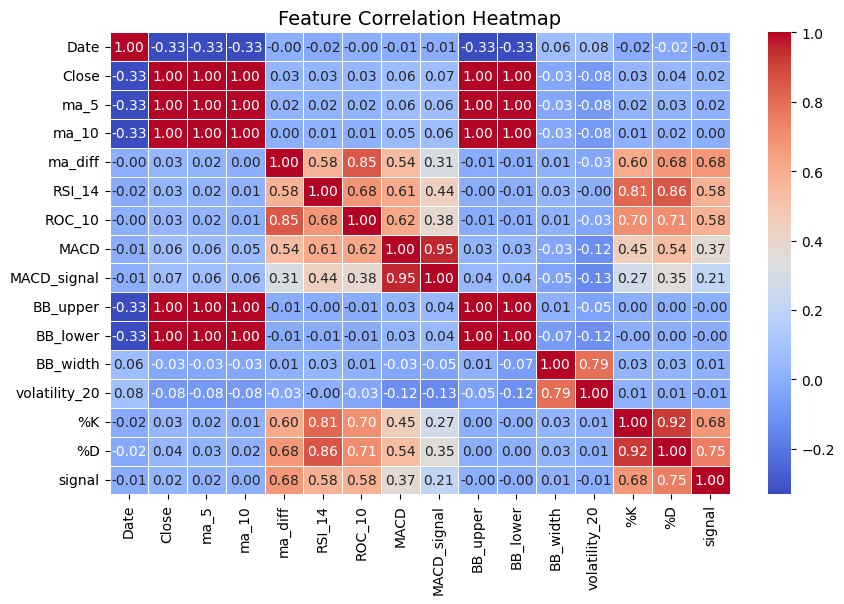

In [42]:
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()


In [43]:

print("\n📊 Original signal distribution:")
print(df["signal"].value_counts(normalize=True))


feature_cols = [
    "ma_5","ma_10","ma_diff",
    "RSI_14","MACD","MACD_signal",
    "BB_upper","BB_lower","BB_width",
    "volatility_20",
    "%K","%D", "ROC_10", "Close"
]

X = df[feature_cols]
y = df["signal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

print("\n📊 Train label distribution:")
print(y_train.value_counts(normalize=True))

print("\n📊 Test label distribution:")
print(y_test.value_counts(normalize=True))


📊 Original signal distribution:
signal
-1    0.507967
 1    0.492010
 0    0.000023
Name: proportion, dtype: float64

📊 Train label distribution:
signal
-1    0.507150
 1    0.492821
 0    0.000029
Name: proportion, dtype: float64

📊 Test label distribution:
signal
-1    0.511232
 1    0.488768
Name: proportion, dtype: float64


In [45]:

pipeline = Pipeline([
    ("classifier", RandomForestClassifier())
])
  
param_grid = {
    "classifier__n_estimators": [200, 500, 700],
    "classifier__max_depth": [5, 10, None, 15, 20],
    "classifier__min_samples_split": [2, 5, 7, 9],
    "classifier__min_samples_leaf": [1, 2, 4, 6, 8]
}

model = GridSearchCV(pipeline, param_grid, cv=2, n_jobs=-1)
model.fit(X_train, y_train)

print("\n✅ Training Complete")
print("Test Accuracy:", model.score(X_test, y_test))
print("Predictions distribution on test set:")
print(pd.Series(model.predict(X_test)).value_counts(normalize=True))


feature_columns = X_train.columns.tolist()
joblib.dump((model, feature_columns), "model.pkl")
print("💾 Model + features saved as model.pkl")


c:\Users\shari\miniconda3\envs\python3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(



✅ Training Complete
Test Accuracy: 1.0
Predictions distribution on test set:
-1    0.511232
 1    0.488768
Name: proportion, dtype: float64
💾 Model + features saved as model.pkl
